In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table

In [13]:
# Load data
# seperated by commas not spaces
data = np.loadtxt("astro_image.csv")
print("Shape:", data.shape)
print("Size:", data.size)
print("Min/Max:", data.min(), data.max())
print("Nonzero entries:", np.count_nonzero(data))


Shape: (1600, 1600)
Size: 2560000
Min/Max: -1.141792366085798e-14 3194.122802734375
Nonzero entries: 2070199


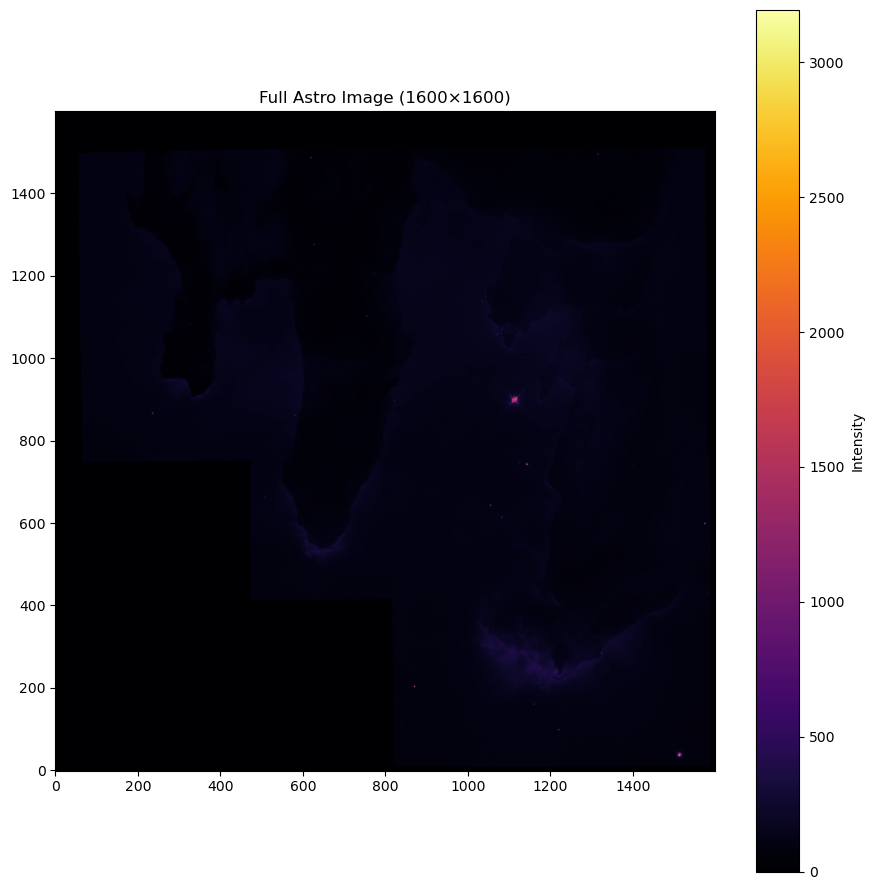

In [14]:
plt.figure(figsize=(9, 9))
plt.imshow(data, cmap="inferno", origin="lower")
plt.colorbar(label="Intensity")
plt.title("Full Astro Image (1600×1600)")
plt.tight_layout()
plt.show()

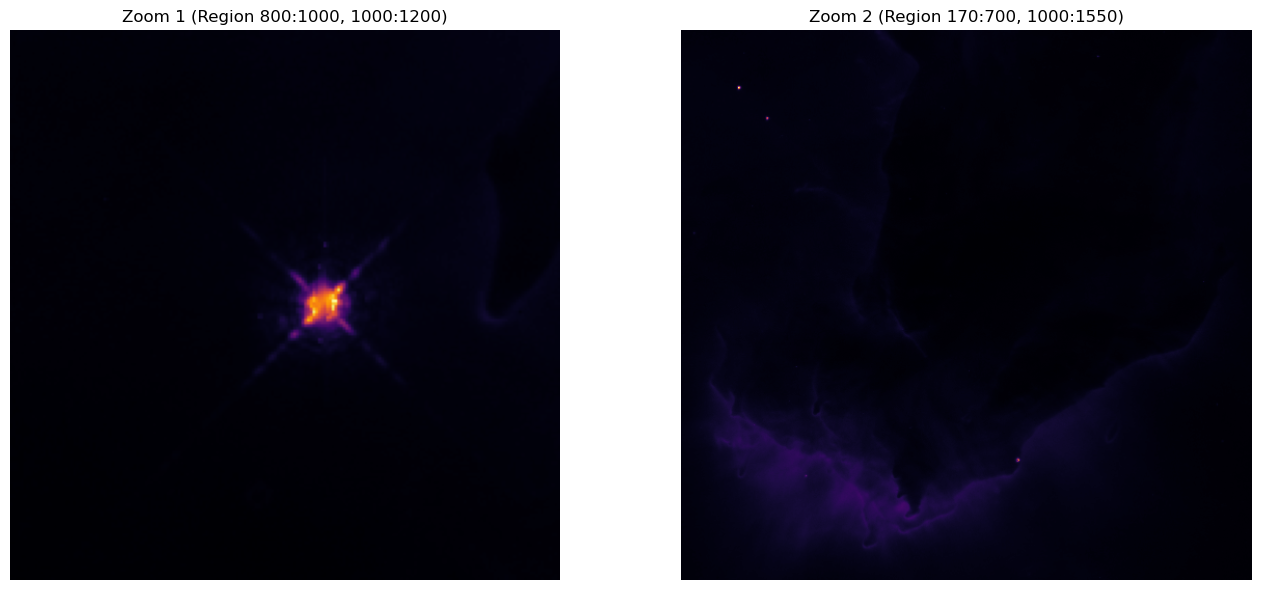

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# --- Zoom region 1 ---
zoom1 = data[800:1000, 1000:1200]  
axs[0].imshow(zoom1, cmap="inferno", origin="lower")
axs[0].set_title("Zoom 1 (Region 800:1000, 1000:1200)")
axs[0].axis("off")

# --- Zoom region 2 ---
zoom2 = data[170:700, 1000:1550] 
axs[1].imshow(zoom2, cmap="inferno", origin="lower")
axs[1].set_title("Zoom 2 (Region 170:700, 1000:1550)")
axs[1].axis("off")

plt.tight_layout()
plt.show()

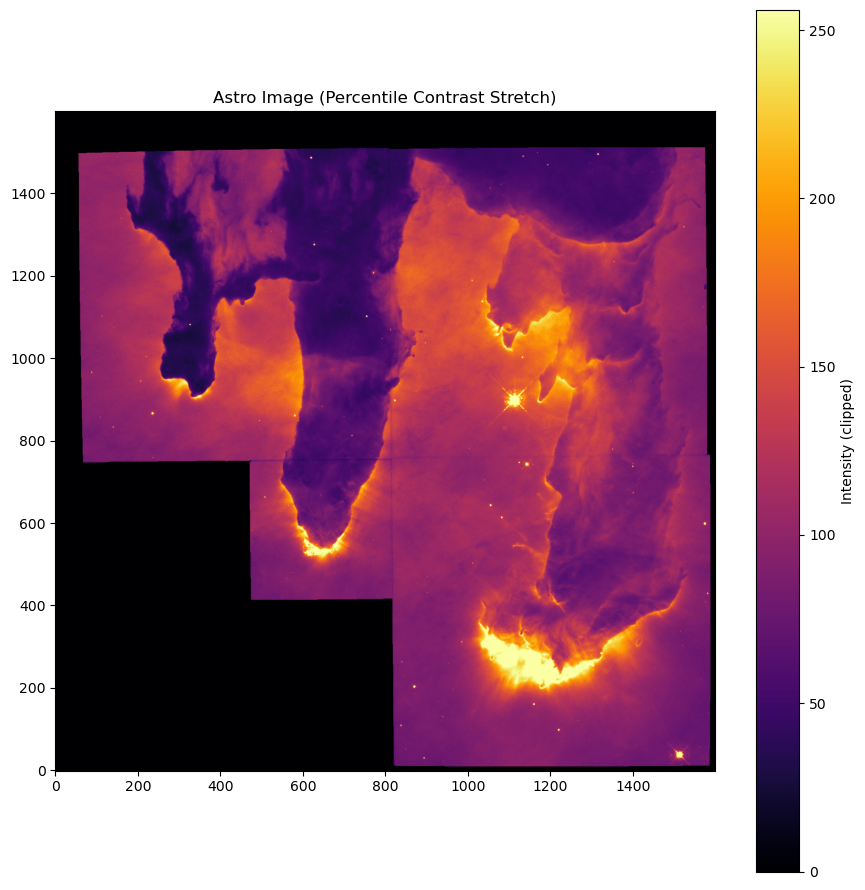

In [40]:
data = np.loadtxt("astro_image.csv")

# Clip extreme values for better contrast
vmin, vmax = np.percentile(data, [1, 99.5])

plt.figure(figsize=(9, 9))
plt.imshow(data, cmap="inferno", origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(label="Intensity (clipped)")
plt.title("Astro Image (Percentile Contrast Stretch)")
plt.tight_layout()
plt.show()

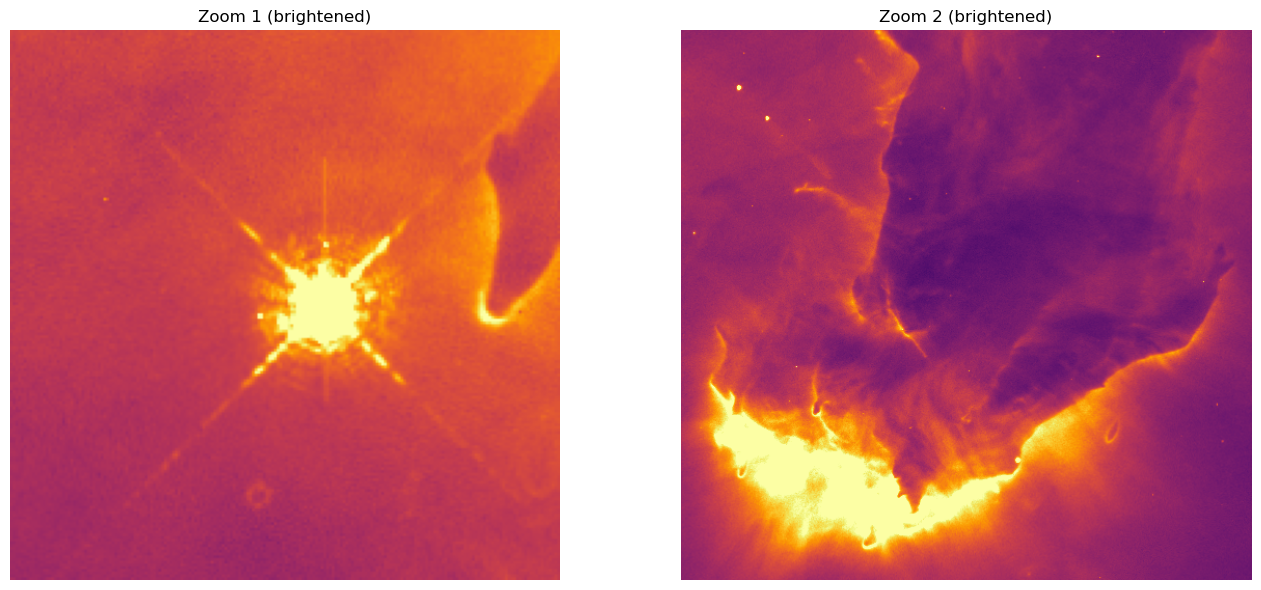

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

vmin, vmax = np.percentile(data, [1, 99.5])

zoom1 = data[800:1000, 1000:1200]
zoom2 = data[170:700, 1000:1550]

axs[0].imshow(zoom1, cmap="inferno", origin="lower", vmin=vmin, vmax=vmax)
axs[0].set_title("Zoom 1 (brightened)")
axs[0].axis("off")

axs[1].imshow(zoom2, cmap="inferno", origin="lower", vmin=vmin, vmax=vmax)
axs[1].set_title("Zoom 2 (brightened)")
axs[1].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
----- Pandas and Ramen -----
1. The dataset has the following columns:

In [32]:
# Load the dataset
df = pd.read_csv("ramen-ratings.csv", encoding="latin1")

# Display column names
df.columns.tolist()

['Review #', 'Brand', 'Variety', 'Style', 'Country', 'Stars', 'Top Ten']

In [ ]:
2. The 27th entry in the dataset has the following style:

In [33]:
# Ramen style of the 27th entry
df.loc[26, 'Style']

'Pack'

In [ ]:
3. There are 355 unique ramen brands in the dataset.

In [34]:
# Number of unique brands
df['Brand'].nunique()

355

In [ ]:
4. The dataset has been sorted alphabetically by brand names.

In [35]:
# Sort dataset by Brand
df_sorted = df.sort_values(by='Brand')
df_sorted.head(10)  # Show first 10 rows as a check

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
229,2351,1 To 3 Noodles,Chatpat Masala,Pack,India,4,NaN
456,2124,7 Select,Nissin Instant Noodles Tom Yum Seafood Creamy ...,Bowl,Thailand,3.5,NaN
463,2117,7 Select,Nissin Instant Noodles Shrimp Ma Nao Lui Suan ...,Bowl,Thailand,4,NaN
877,1703,7 Select/Nissin,Super Tom Yum Shrimp,Cup,Thailand,3.5,NaN
911,1669,A-One,Mi Ly Instant Noodles Mi Chay Vegetarian Flavor,Cup,Vietnam,1.25,NaN
947,1633,A-One,Mi Ly Instant Noodles Mi Bo Beef Flavor,Cup,Vietnam,3.5,NaN
1016,1564,A-One,MÃ¬ Ly Instant Noodles MÃ¬ Thá»t XÃ o Pork Fl...,Cup,Vietnam,3,NaN
1289,1291,A-One,MÃ¬ Ly Instant Noodles MÃ¬ TÃ´m Shrimp Flavor,Cup,Vietnam,3.25,NaN
1252,1328,A-Sha Dry Noodle,Hello Kitty La Wei (Spicy Flavor),Pack,Taiwan,3.75,NaN
424,2156,A-Sha Dry Noodle,Chow Mein Oyster Sauce BBQ Flavor,Tray,Taiwan,2,NaN


In [ ]:
5. There are 49 ramen brands produced in the USA.

In [36]:
# Count unique brands in the USA
usa_brands = df[df['Country'] == 'USA']['Brand'].nunique()
usa_brands

49

In [ ]:
6. There are 27 ramen brands in the USA that make pack-style ramen.

In [37]:
# Count unique brands in the USA that make Pack-style ramen
usa_pack_brands = df[(df['Country'] == 'USA') & (df['Style'].str.contains('Pack', case=False))]['Brand'].nunique()
usa_pack_brands

27

In [ ]:
Challenge: These are the brands that have been listed in the top ten (Top Ten column is not NaN):
MAMA, Prima Taste, Prima, Tseng Noodles, Wugudaochang,
A-Sha Dry Noodle, MyKuali, CarJEN, Maruchan, Mamee,
Mama, Sapporo Ichiban, Nongshim, Samyang Foods, Paldo,
Indomie, Koka, Mi Sedaap, Nissin, Myojo, Doll

In [38]:
# Brands that have a non-NaN entry in 'Top Ten'
top_ten_brands = df[df['Top Ten'].notna()]['Brand'].unique()
top_ten_brands

array(['MAMA', 'Prima Taste', 'Prima', 'Tseng Noodles', 'Wugudaochang',
       'A-Sha Dry Noodle', 'MyKuali', 'CarJEN', 'Maruchan', 'Mamee',
       'Mama', 'Sapporo Ichiban', 'Nongshim', 'Samyang Foods', 'Paldo',
       'Indomie', 'Koka', 'Mi Sedaap', 'Nissin', 'Myojo', 'Doll'],
      dtype=object)

In [ ]:
----- Linear Regression -----

In [44]:
# Read the data file
data_table = Table.read("global_CCl4_MM.dat", format='ascii')

print(data_table[:5])

CCl4ottoyr CCl4ottomon CCl4ottoNHm ... CCl4ottoSHsd CCl4ottoGLm CCl4ottoGLsd
---------- ----------- ----------- ... ------------ ----------- ------------
      1996           1         nan ...          nan         nan          nan
      1996           2         nan ...          nan         nan          nan
      1996           3         nan ...          nan         nan          nan
      1996           4     105.318 ...        0.238     104.144        0.155
      1996           5     105.032 ...        0.287     103.893        0.174


In [47]:
# Convert Astropy Table to Pandas DataFrame
df = data_table.to_pandas()

# Print column names
print(df.columns.tolist())

df = df[['CCl4ottoyr', 'CCl4ottoGLm', 'CCl4ottoGLsd']]

# Rename
df.columns = ['date', 'global_mean_conc', 'global_mean_conc_sd']

print(df.head())

['CCl4ottoyr', 'CCl4ottomon', 'CCl4ottoNHm', 'CCl4ottoNHsd', 'CCl4ottoSHm', 'CCl4ottoSHsd', 'CCl4ottoGLm', 'CCl4ottoGLsd']
   date  global_mean_conc  global_mean_conc_sd
0  1996               NaN                  NaN
1  1996               NaN                  NaN
2  1996               NaN                  NaN
3  1996           104.144                0.155
4  1996           103.893                0.174


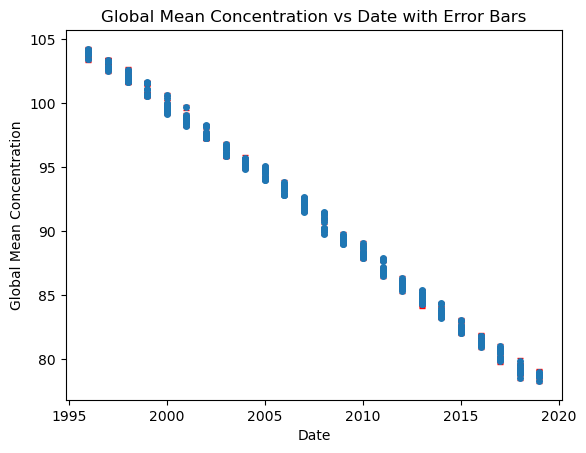

In [49]:
plt.errorbar(df['date'], df['global_mean_conc'], yerr=df['global_mean_conc_sd'], fmt='o', markersize=4, ecolor='red', capsize=2)
plt.xlabel("Date")
plt.ylabel("Global Mean Concentration")
plt.title("Global Mean Concentration vs Date with Error Bars")
plt.show()

In [57]:
# Remove any rows with NaN or zero in the uncertainty
df_clean = df.dropna(subset=['global_mean_conc', 'global_mean_conc_sd'])
df_clean = df_clean[df_clean['global_mean_conc_sd'] > 0]

# Model Fit
coeffs = np.polyfit(
    df_clean['date'], 
    df_clean['global_mean_conc'], 
    deg=1, 
    w=1/df_clean['global_mean_conc_sd']
)
m, b = coeffs
print(f"Fitted line: y = {m:.4f} x + {b:.4f}")

Fitted line: y = -1.1520 x + 2403.7901


In [59]:
# Reduced chi-squared
N = len(df)
chi2_red = np.sum(((df['global_mean_conc'] - y_fit) / df['global_mean_conc_sd'])**2) / (N - 1)
print(f"Reduced chi-square: {chi2_red:.2f}")

Reduced chi-square: 12.77


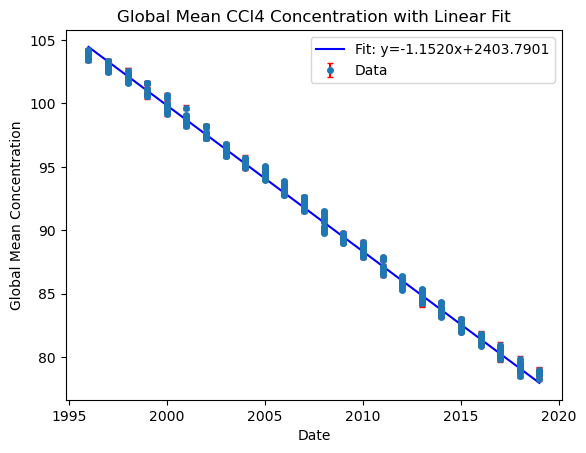

The model is a good one when plotted and fitted the only indicaiton that is concerning is the reduced chi-squared, it turned out to be 12.77 which is much larger than 1 so it is not very good or credible but still seems good.


In [64]:
# Use the cleaned data used for fitting
x = df_clean['date']
y = df_clean['global_mean_conc']
yerr = df_clean['global_mean_conc_sd']

# Compute fitted values
y_fit = m * x + b

# Plot
plt.errorbar(x, y, yerr=yerr, fmt='o', markersize=4, ecolor='red', capsize=2, label='Data')
plt.plot(x, y_fit, 'b-', label=f'Fit: y={m:.4f}x+{b:.4f}')
plt.xlabel("Date")
plt.ylabel("Global Mean Concentration")
plt.title("Global Mean CCl4 Concentration with Linear Fit")
plt.legend()
plt.show()

print("The model is a good one when plotted and fitted the only indicaiton that is concerning is the reduced chi-squared, it turned out to be 12.77 which is much larger than 1 so it is not very good or credible but still seems good.")